# Calidad del Aire en Santiago — Análisis de Exposome

**Objetivo:** Construir un indicador geoespacial de **calidad del aire por comuna** en la Región Metropolitana de Santiago, usando exclusivamente datos de libre acceso y **sin API key**.

Es el notebook hermano del de acceso a salud (`santiago_healthcare_access.ipynb`): ambos comparten la misma unidad geográfica (comuna, columna `name`) para poder **cruzarse**. Es un ejemplo directo de un indicador del **exposome** ambiental que BrainLat necesita derivar desde la ubicación residencial de los participantes.

**Por qué PM2.5 y NO₂:** son los contaminantes con mayor evidencia epidemiológica en deterioro cognitivo y riesgo de demencia. El **PM2.5** (material particulado fino) es además el contaminante crítico de Santiago: en invierno la inversión térmica atrapa el smog en la cuenca y la ciudad supera de forma crónica las guías de la OMS.

**Fuentes de datos (abiertas, reproducibles):**
- [Open-Meteo Air Quality API](https://open-meteo.com/en/docs/air-quality-api) — reanálisis **CAMS** (Copernicus), sin registro ni API key. Grilla ≈11 km de PM2.5, NO₂, PM10 y O₃.
- [SINCA](https://sinca.mma.gob.cl/) — Sistema de Información Nacional de Calidad del Aire (MMA, Chile): estaciones oficiales de monitoreo, usadas como validación de terreno.
- Límites comunales desde OpenStreetMap (`admin_level` 8) vía `osmnx`.

**Indicadores generados (media anual 2024):**
- PM2.5 y NO₂ medios por comuna (µg/m³)
- Razón respecto a la guía OMS 2021 (PM2.5: 5 µg/m³ · NO₂: 10 µg/m³)


In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
import requests
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

print(f'osmnx    : {ox.__version__}')
print(f'geopandas: {gpd.__version__}')
print(f'folium   : {folium.__version__}')
print(f'requests : {requests.__version__}')

osmnx    : 2.1.0
geopandas: 1.1.3
folium   : 0.20.0
requests : 2.34.2


## 1. Límites comunales (OpenStreetMap, admin_level 8)

Misma extracción de comunas que el notebook de salud (para cruzar por `name`), pero **recortada al límite oficial de la Región Metropolitana**: nos quedamos solo con las **52 comunas** de la RM. OSM devuelve además polígonos limítrofes (regiones vecinas y departamentos argentinos de Mendoza) y entidades que no son comunas (provincias, la región misma); los descartamos quedándonos con los polígonos cuyo centroide cae dentro de la RM y cuyo nombre no es de provincia/región/departamento/distrito.

In [2]:
REGION = "Región Metropolitana de Santiago, Chile"

print("Descargando límites comunales desde OSM...")
commune_tags = {"boundary": "administrative", "admin_level": "8"}
gdf_communes_raw = ox.features_from_place(REGION, tags=commune_tags)

gdf_communes = gdf_communes_raw[
    gdf_communes_raw.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

# CRS métrico chileno (UTM 19S) para áreas y mapas
gdf_communes = gdf_communes.to_crs(epsg=32719)
gdf_communes = (
    gdf_communes[["name", "geometry"]]
    .dropna(subset=["name"])
    .dissolve(by="name")
    .reset_index()
)

# Recortar a las 52 comunas oficiales de la RM:
#  (1) centroide dentro del límite regional (admin_level 4)
#  (2) excluir entidades que no son comunas (provincias, región, dptos/distritos argentinos)
NON_COMUNA = ("Provincia", "Región", "Dirección", "Departamento", "Distrito")
rm_geom = ox.geocode_to_gdf(REGION).to_crs(epsg=32719).geometry.iloc[0]
gdf_communes = gdf_communes[
    gdf_communes.geometry.centroid.within(rm_geom)
    & ~gdf_communes["name"].str.startswith(NON_COMUNA)
].reset_index(drop=True)

gdf_communes["area_km2"] = gdf_communes.geometry.area / 1e6
print(f"Comunas oficiales de la RM: {len(gdf_communes)}")
gdf_communes.head()

Descargando límites comunales desde OSM...
Comunas oficiales de la RM: 52


,name,geometry,area_km2
0,Alhué,"POLYGON ((287599.305 6232129.935, 287637.866 6...",843.723157
1,Buin,"POLYGON ((324837.929 6258234.358, 324900.841 6...",217.487077
2,Calera de Tango,"POLYGON ((328515.113 6276680.615, 328527.714 6...",73.046707
3,Cerrillos,"POLYGON ((338404.757 6290816.631, 338489.9 629...",16.919765
4,Cerro Navia,"POLYGON ((334318.581 6301418.812, 334341.627 6...",11.140992


## 2. Calidad del aire — Open-Meteo (reanálisis CAMS)

Muestreamos una **grilla de 0.1° (≈11 km)** sobre la Región Metropolitana y pedimos a Open-Meteo la serie horaria de 2024 de PM2.5 y NO₂. Promediamos a **media anual** por punto. La descarga usa reintentos con _backoff_ (el tier gratuito limita peticiones pesadas) y caché parcial reanudable.

> **Nota de resolución:** CAMS tiene ≈11 km de resolución, así que comunas urbanas vecinas pueden caer en la misma celda y compartir valor. El gradiente robusto que captura es el **oriente alto (cordillera, más limpio) vs. el poniente/sur de la cuenca (más contaminado)**. Para validar el terreno superponemos las estaciones oficiales SINCA.

El resultado se cachea en `cache/air_quality_grid_2024.csv` para no volver a llamar a la API en re-ejecuciones.

In [3]:
import os, time

CACHE = "cache/air_quality_grid_2024.csv"
PARTIAL = CACHE + ".partial"
YEAR_START, YEAR_END = "2024-01-01", "2024-12-31"
URL = "https://air-quality-api.open-meteo.com/v1/air-quality"
VARS = ["pm2_5", "nitrogen_dioxide"]
os.makedirs("cache", exist_ok=True)


def mean_clean(vals):
    v = [x for x in vals if x is not None]
    return float(np.mean(v)) if v else np.nan


def fetch_chunk(chunk, retries=6):
    # GET con reintentos y backoff respetando Retry-After (tier gratuito)
    params = {
        "latitude":  ",".join(str(p[0]) for p in chunk),
        "longitude": ",".join(str(p[1]) for p in chunk),
        "hourly": ",".join(VARS),
        "start_date": YEAR_START, "end_date": YEAR_END,
        "timezone": "America/Santiago",
    }
    for attempt in range(retries):
        r = requests.get(URL, params=params, timeout=120)
        if r.status_code == 429:
            wait = int(r.headers.get("Retry-After", 0)) or min(70, 8 * 2 ** attempt)
            print(f"    rate-limit 429 → espero {wait}s (intento {attempt + 1}/{retries})")
            time.sleep(wait)
            continue
        r.raise_for_status()
        data = r.json()
        return data if isinstance(data, list) else [data]
    raise RuntimeError("Open-Meteo: rate-limit persistente tras varios reintentos")


if os.path.exists(CACHE):
    df_grid = pd.read_csv(CACHE)
    print(f"Grilla cargada desde cache: {len(df_grid)} puntos")
else:
    lat0, lat1 = -34.5, -32.9
    lon0, lon1 = -71.8, -69.8
    grid_lats = np.arange(lat0, lat1 + 1e-9, 0.1)
    grid_lons = np.arange(lon0, lon1 + 1e-9, 0.1)
    pts = [(round(la, 3), round(lo, 3)) for la in grid_lats for lo in grid_lons]

    # Reanudar desde caché parcial si existe
    rows, done = [], set()
    if os.path.exists(PARTIAL):
        prev = pd.read_csv(PARTIAL)
        rows = prev.to_dict("records")
        done = {(round(r["lat"], 3), round(r["lon"], 3)) for r in rows}
        print(f"Reanudando: {len(done)} puntos ya en caché parcial")
    todo = [p for p in pts if p not in done]
    print(f"Muestreando {len(todo)}/{len(pts)} puntos (grilla 0.1° ≈ 11 km) en Open-Meteo...")

    CHUNK = 40
    for i in range(0, len(todo), CHUNK):
        ch = todo[i:i + CHUNK]
        data = fetch_chunk(ch)
        for (la, lo), loc in zip(ch, data):
            h = loc["hourly"]
            rows.append({"lat": la, "lon": lo,
                         "pm25": mean_clean(h["pm2_5"]),
                         "no2":  mean_clean(h["nitrogen_dioxide"])})
        pd.DataFrame(rows).to_csv(PARTIAL, index=False)   # checkpoint
        print(f"  {len(rows)}/{len(pts)} puntos")
        time.sleep(8)

    df_grid = pd.DataFrame(rows)
    df_grid.to_csv(CACHE, index=False)
    if os.path.exists(PARTIAL):
        os.remove(PARTIAL)
    print(f"Guardado en {CACHE}")

# GeoDataFrame de la grilla
gdf_grid = gpd.GeoDataFrame(
    df_grid, geometry=gpd.points_from_xy(df_grid.lon, df_grid.lat), crs="EPSG:4326",
)
print(f"\nMedia regional 2024 — PM2.5={df_grid.pm25.mean():.1f}  NO₂={df_grid.no2.mean():.1f} µg/m³")
df_grid[["pm25", "no2"]].describe().round(2)

Grilla cargada desde cache: 357 puntos

Media regional 2024 — PM2.5=9.6  NO₂=8.9 µg/m³


,pm25,no2
count,357.00,357.00
mean,9.63,8.92
std,5.47,9.51
min,2.33,0.17
25%,6.77,2.61
50%,9.20,6.36
75%,11.33,12.55
max,28.77,42.63


## 3. Agregación por comuna y guías OMS

Asignamos cada punto de grilla a su comuna (join espacial) y promediamos. Las comunas demasiado pequeñas para contener un punto de grilla reciben el valor del punto más cercano a su centroide. Calculamos la **razón respecto a la guía OMS 2021**.

In [4]:
gdf_grid_proj = gdf_grid.to_crs(epsg=32719)
gdf_comm = gdf_communes[["name", "area_km2", "geometry"]].copy()

# (a) media de los puntos de grilla DENTRO de cada comuna
joined = gpd.sjoin(gdf_grid_proj, gdf_comm, how="inner", predicate="within")
agg = joined.groupby("name").agg(
    pm25_mean=("pm25", "mean"),
    no2_mean=("no2", "mean"),
    n_grid=("pm25", "size"),
).reset_index()

# (b) fallback: punto de grilla más cercano al centroide (para comunas sin puntos)
cent = gdf_comm.copy()
cent["geometry"] = cent.geometry.centroid
near = gpd.sjoin_nearest(
    cent, gdf_grid_proj[["pm25", "no2", "geometry"]], how="left"
).groupby("name").first().reset_index()
base = near[["name", "pm25", "no2"]].rename(columns={
    "pm25": "pm25_mean", "no2": "no2_mean"})

# combinar: interior donde exista, si no el más cercano
gdf_result = gdf_comm.merge(base, on="name", how="left")
gdf_result = gdf_result.merge(agg, on="name", how="left", suffixes=("", "_in"))
for c in ["pm25_mean", "no2_mean"]:
    gdf_result[c] = gdf_result[c + "_in"].fillna(gdf_result[c])
gdf_result = gdf_result.drop(columns=[c + "_in" for c in ["pm25_mean", "no2_mean"]])
gdf_result["n_grid"] = gdf_result["n_grid"].fillna(0).astype(int)

# razón respecto a la guía OMS 2021
WHO = {"pm25": 5.0, "no2": 10.0}
gdf_result["pm25_who_ratio"] = (gdf_result["pm25_mean"] / WHO["pm25"]).round(2)
gdf_result["no2_who_ratio"] = (gdf_result["no2_mean"] / WHO["no2"]).round(2)

print("Top 10 comunas con peor PM2.5 (media anual 2024):")
print(gdf_result.sort_values("pm25_mean", ascending=False)[
    ["name", "pm25_mean", "no2_mean", "pm25_who_ratio", "n_grid"]
].head(10).round(2).to_string(index=False))
print(f"\nComunas que superan la guía OMS de PM2.5 (5 µg/m³): "
      f"{(gdf_result['pm25_mean'] > 5).sum()} / {len(gdf_result)}")

Top 10 comunas con peor PM2.5 (media anual 2024):
               name  pm25_mean  no2_mean  pm25_who_ratio  n_grid
        La Cisterna      28.77     42.63            5.75       0
   Estación Central      28.77     42.63            5.75       0
Pedro Aguirre Cerda      28.77     42.63            5.75       0
               Buin      28.77     42.63            5.75       2
              Maipú      28.77     42.63            5.75       2
           Peñaflor      28.77     42.63            5.75       1
          Lo Espejo      28.77     42.63            5.75       0
         San Miguel      28.77     42.63            5.75       0
      Isla de Maipo      28.77     42.63            5.75       2
           Santiago      28.77     42.63            5.75       0

Comunas que superan la guía OMS de PM2.5 (5 µg/m³): 52 / 52


## 4. Mapa pub-quality — Superficie de PM2.5 + estaciones SINCA

Superficie continua de PM2.5 (interpolación de la grilla CAMS) recortada a las comunas urbanas de Santiago, con los límites comunales y las estaciones oficiales **SINCA** superpuestas como validación de terreno.

Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.


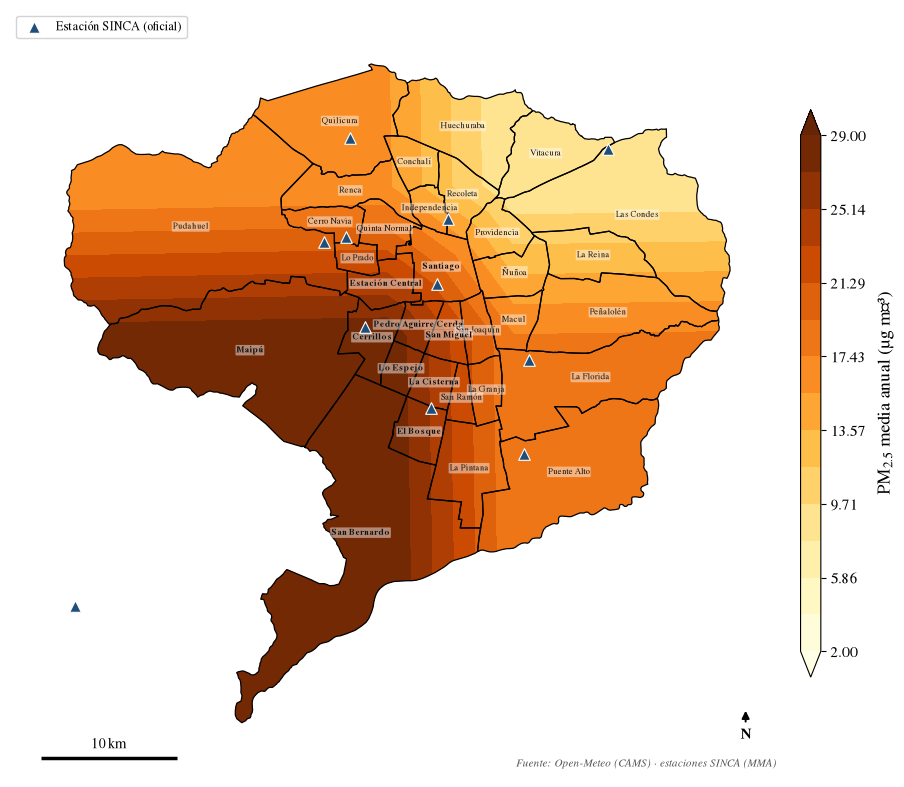

Mapa guardado: figures/air_quality_santiago_pub.png


In [5]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# ── Estaciones oficiales SINCA en la RM (red MACAM, MMA) ──────────────────────
sinca = pd.DataFrame([
    ("Cerrillos",        -33.4925, -70.7176),
    ("Cerro Navia",      -33.4326, -70.7320),
    ("El Bosque",        -33.5469, -70.6664),
    ("Independencia",    -33.4220, -70.6510),
    ("La Florida",       -33.5163, -70.5882),
    ("Las Condes",       -33.3766, -70.5230),
    ("Parque O'Higgins", -33.4647, -70.6601),
    ("Pudahuel",         -33.4356, -70.7494),
    ("Puente Alto",      -33.5790, -70.5933),
    ("Quilicura",        -33.3672, -70.7270),
    ("Talagante",        -33.6745, -70.9520),
], columns=["estacion", "lat", "lon"])
gdf_sinca = gpd.GeoDataFrame(
    sinca, geometry=gpd.points_from_xy(sinca.lon, sinca.lat), crs="EPSG:4326")

LABEL_ALL = [
    "Providencia", "Santiago", "Ñuñoa", "Las Condes", "Vitacura",
    "Maipú", "Puente Alto", "La Florida", "San Bernardo",
    "Independencia", "Cerro Navia", "San Ramón", "Lo Prado",
    "Recoleta", "Conchalí", "Huechuraba", "Quilicura",
    "Peñalolén", "Macul", "San Miguel", "La Cisterna",
    "El Bosque", "La Pintana", "Pedro Aguirre Cerda",
    "Lo Espejo", "Renca", "Cerrillos",
    "Pudahuel", "Estación Central", "Quinta Normal",
    "San Joaquín", "La Reina", "La Granja",
]

# Datos en CRS métrico
gdf_grid_m = gdf_grid.to_crs(epsg=32719)
gx = gdf_grid_m.geometry.x.values
gy = gdf_grid_m.geometry.y.values
gz = gdf_grid_m["pm25"].values
ok = np.isfinite(gz)
gx, gy, gz = gx[ok], gy[ok], gz[ok]

gdf_disp = gdf_result[(gdf_result["area_km2"] < 5000) &
                      (gdf_result["name"].isin(LABEL_ALL))].to_crs(epsg=32719).copy()
gdf_sinca_m = gdf_sinca.to_crs(epsg=32719)

minx, miny, maxx, maxy = gdf_disp.total_bounds
buf = 4_000
X0, X1 = minx - buf, maxx + buf
Y0, Y1 = miny - buf, maxy + buf

plt.rcParams.update({
    "font.family": "STIXGeneral", "mathtext.fontset": "stix",
    "font.size": 11, "axes.linewidth": 0.8,
})

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

levels = np.linspace(np.floor(gz.min()), np.ceil(np.nanpercentile(gz, 99)), 15)
tcf = ax.tricontourf(gx, gy, gz, levels=levels, cmap="YlOrBr", extend="both")

# Recortar la superficie a la silueta de las comunas urbanas
try:
    dissolved = gdf_disp.geometry.union_all()
    polys = dissolved.geoms if dissolved.geom_type == "MultiPolygon" else [dissolved]
    verts, codes = [], []
    for poly in polys:
        for ring in [poly.exterior, *poly.interiors]:
            xy = np.asarray(ring.coords)
            if len(xy) < 3:
                continue
            verts.extend(xy)
            codes.append(Path.MOVETO)
            codes.extend([Path.LINETO] * (len(xy) - 2))
            codes.append(Path.CLOSEPOLY)
    clip_patch = PathPatch(Path(verts, codes), transform=ax.transData, fc="none", ec="none")
    ax.add_patch(clip_patch)
    tcf.set_clip_path(clip_patch)
except Exception as e:
    print("Aviso: no se pudo recortar la superficie:", e)

# Límites comunales + etiquetas
gdf_disp.boundary.plot(ax=ax, color="black", linewidth=0.9)
q70 = gdf_disp["pm25_mean"].quantile(0.7)
for _, row in gdf_disp.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, row["name"], fontsize=6.3, ha="center", va="center", color="#111111",
            fontweight="bold" if row["pm25_mean"] > q70 else "normal",
            bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.45))

# Estaciones SINCA
in_view = gdf_sinca_m.cx[X0:X1, Y0:Y1]
ax.scatter(in_view.geometry.x, in_view.geometry.y, marker="^", s=70,
           facecolor="#1f4e79", edgecolor="white", linewidth=0.8, zorder=6,
           label="Estación SINCA (oficial)")

ax.set_xlim(X0, X1)
ax.set_ylim(Y0, Y1)

cbar = fig.colorbar(tcf, ax=ax, fraction=0.025, pad=0.02, aspect=28)
cbar.set_label("PM$_{2.5}$ media anual (µg m⁻³)", fontsize=13, labelpad=8)
cbar.outline.set_linewidth(0.8)
cbar.ax.tick_params(labelsize=11, width=0.8)

dx, dy = X1 - X0, Y1 - Y0
ax.annotate("N", xy=(X1 - dx * 0.05, Y0 + dy * 0.09),
            xytext=(X1 - dx * 0.05, Y0 + dy * 0.05),
            fontsize=11, ha="center", fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.4))
sb_len = 10_000
sb_x, sb_y = X0 + dx * 0.04, Y0 + dy * 0.025
ax.plot([sb_x, sb_x + sb_len], [sb_y, sb_y], color="black", lw=2.5, solid_capstyle="butt")
ax.text(sb_x + sb_len / 2, sb_y + dy * 0.008, "10 km", ha="center", va="bottom", fontsize=10)

ax.legend(loc="upper left", fontsize=9, frameon=True, framealpha=0.85)
ax.text(0.99, 0.01, "Fuente: Open-Meteo (CAMS) · estaciones SINCA (MMA)",
        transform=ax.transAxes, fontsize=8, ha="right", va="bottom",
        color="#555555", fontstyle="italic")
ax.set_axis_off()
plt.tight_layout(pad=0.5)
plt.savefig("figures/air_quality_santiago_pub.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("Mapa guardado: figures/air_quality_santiago_pub.png")

## 5. Mapa interactivo con Folium

Choropleth de PM2.5 por comuna (pasa el cursor para ver métricas) con las estaciones SINCA como capa superpuesta.

In [6]:
gdf_wgs = gdf_result.to_crs(epsg=4326).copy()
for c in ["pm25_mean", "no2_mean", "pm25_who_ratio", "no2_who_ratio"]:
    gdf_wgs[c] = gdf_wgs[c].round(2)

m = folium.Map(location=[-33.52, -70.66], zoom_start=10, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=gdf_wgs.__geo_interface__,
    data=gdf_wgs,
    columns=["name", "pm25_mean"],
    key_on="feature.properties.name",
    fill_color="YlOrBr",
    fill_opacity=0.75,
    line_opacity=0.3,
    legend_name="PM2.5 media anual (µg/m³)",
    nan_fill_color="lightgrey",
).add_to(m)

folium.GeoJson(
    gdf_wgs.__geo_interface__,
    style_function=lambda x: {"fillColor": "transparent", "color": "transparent"},
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "pm25_mean", "no2_mean", "pm25_who_ratio", "no2_who_ratio"],
        aliases=["Comuna", "PM2.5 (µg/m³)", "NO₂ (µg/m³)",
                 "PM2.5 vs OMS (×)", "NO₂ vs OMS (×)"],
        localize=True,
    ),
).add_to(m)

fg = folium.FeatureGroup(name="Estaciones SINCA (oficiales)")
for _, r in gdf_sinca.iterrows():
    folium.Marker(
        [r["lat"], r["lon"]],
        tooltip=f"SINCA · {r['estacion']}",
        icon=folium.Icon(color="darkblue", icon="cloud"),
    ).add_to(fg)
fg.add_to(m)

folium.LayerControl().add_to(m)
m.save("maps/air_quality_santiago.html")
print("Mapa interactivo guardado: maps/air_quality_santiago.html")
m

Mapa interactivo guardado: maps/air_quality_santiago.html


## 6. Ranking comunal y brecha de exposición

Todas las comunas de la RM ordenadas por PM2.5. La línea verde marca la guía OMS 2021 (5 µg/m³): toda la cuenca la supera ampliamente.

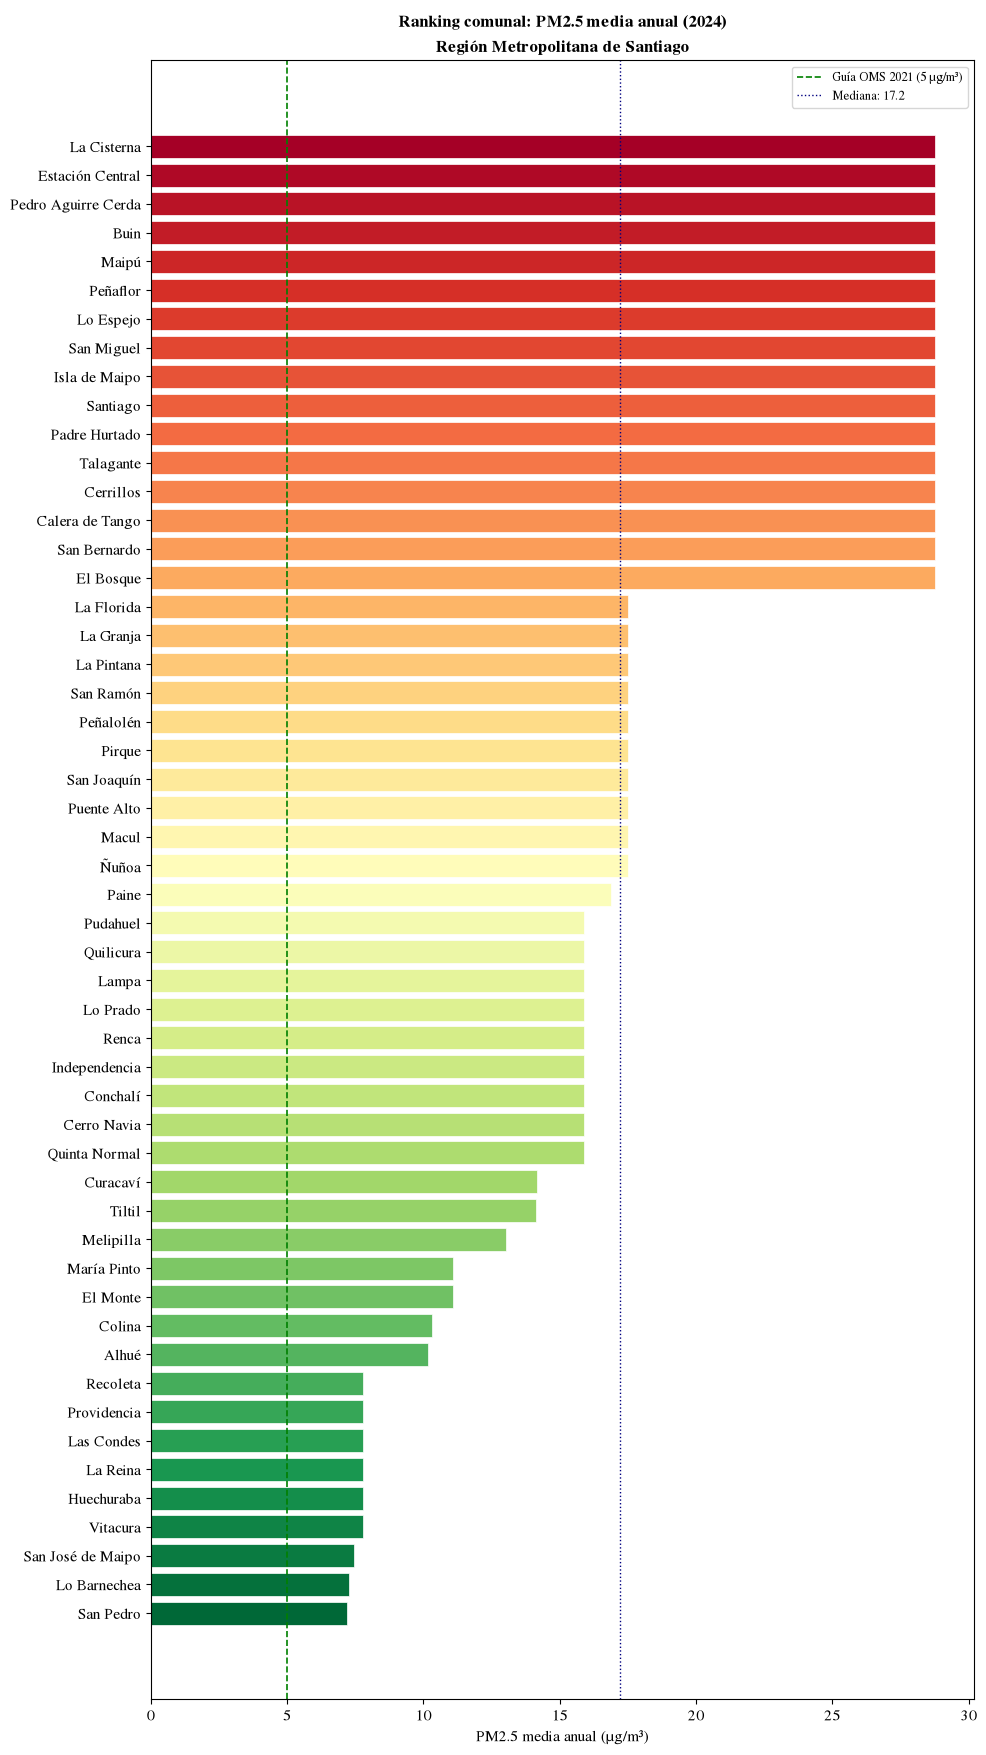


--- Brecha de exposición a PM2.5 ---
  Peor  (más PM2.5): La Cisterna → 28.8 µg/m³  (5.8× OMS)
  Mejor (menos PM2.5): San Pedro → 7.2 µg/m³  (1.4× OMS)
  Todas superan la guía OMS de PM2.5: True


In [7]:
df_ranked = (
    gdf_result[["name", "pm25_mean", "no2_mean", "pm25_who_ratio"]]
    .dropna(subset=["pm25_mean"])
    .sort_values("pm25_mean", ascending=False)
    .reset_index(drop=True)
)
df_ranked.index += 1

fig, ax = plt.subplots(figsize=(10, max(6, len(df_ranked) * 0.34)))
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(df_ranked)))   # rojo = peor (más PM2.5)
ax.barh(df_ranked["name"], df_ranked["pm25_mean"], color=colors,
        edgecolor="white", linewidth=0.5)
ax.set_xlabel("PM2.5 media anual (µg/m³)", fontsize=11)
ax.set_title("Ranking comunal: PM2.5 media anual (2024)\nRegión Metropolitana de Santiago",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
ax.axvline(5, color="green", linestyle="--", linewidth=1.2, label="Guía OMS 2021 (5 µg/m³)")
ax.axvline(df_ranked["pm25_mean"].median(), color="navy", linestyle=":",
           linewidth=1, label=f'Mediana: {df_ranked["pm25_mean"].median():.1f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/air_quality_ranking_santiago.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- Brecha de exposición a PM2.5 ---")
print(f"  Peor  (más PM2.5): {df_ranked.iloc[0]['name']} → "
      f"{df_ranked.iloc[0]['pm25_mean']:.1f} µg/m³  ({df_ranked.iloc[0]['pm25_who_ratio']:.1f}× OMS)")
print(f"  Mejor (menos PM2.5): {df_ranked.iloc[-1]['name']} → "
      f"{df_ranked.iloc[-1]['pm25_mean']:.1f} µg/m³  ({df_ranked.iloc[-1]['pm25_who_ratio']:.1f}× OMS)")
print(f"  Todas superan la guía OMS de PM2.5: {(df_ranked['pm25_mean'] > 5).all()}")

## 7. Exportar indicadores

Guardamos los indicadores por comuna en CSV (listo para cruzar con el indicador de salud y con datos clínicos/censales) y en GeoJSON para GIS.

In [8]:
df_export = gdf_result.drop(columns="geometry").copy()
for c in ["pm25_mean", "no2_mean"]:
    df_export[c] = df_export[c].round(2)
df_export["area_km2"] = df_export["area_km2"].round(2)
df_export.to_csv("data/processed/air_quality_exposome_rm_santiago.csv", index=False)

gdf_wgs.to_file("data/processed/air_quality_exposome_rm_santiago.geojson", driver="GeoJSON")

print("Archivos exportados:")
print("  data/processed/air_quality_exposome_rm_santiago.csv     — indicadores por comuna")
print("  data/processed/air_quality_exposome_rm_santiago.geojson — capa geoespacial (QGIS/GEE)")
print(f"\nDataset final: {len(df_export)} comunas × {len(df_export.columns)} variables")
print("Columnas:", list(df_export.columns))
df_export.sort_values("pm25_mean", ascending=False).head()

Archivos exportados:
  data/processed/air_quality_exposome_rm_santiago.csv     — indicadores por comuna
  data/processed/air_quality_exposome_rm_santiago.geojson — capa geoespacial (QGIS/GEE)

Dataset final: 52 comunas × 7 variables
Columnas: ['name', 'area_km2', 'pm25_mean', 'no2_mean', 'n_grid', 'pm25_who_ratio', 'no2_who_ratio']


,name,area_km2,pm25_mean,no2_mean,n_grid,pm25_who_ratio,no2_who_ratio
14,La Cisterna,10.01,28.77,42.63,0,5.75,4.26
10,Estación Central,14.29,28.77,42.63,0,5.75,4.26
30,Pedro Aguirre Cerda,8.64,28.77,42.63,0,5.75,4.26
1,Buin,217.49,28.77,42.63,2,5.75,4.26
25,Maipú,137.61,28.77,42.63,2,5.75,4.26


## 8. (Opcional) Validación satelital — NO₂ Sentinel-5P vía Google Earth Engine

Sección **opcional**: contrasta el NO₂ de CAMS con el satélite **Sentinel-5P TROPOMI** (ESA/Copernicus) vía Google Earth Engine. Requiere una cuenta GEE + un proyecto GCP. Si GEE no está autenticado, la celda se **omite con gracia** y el notebook corre completo igual.

In [9]:
GEE_PROJECT = "ee-bayalainostroza"   # ← tu proyecto Earth Engine

try:
    import ee, json
    ee.Initialize(project=GEE_PROJECT)
    print(f"GEE inicializado → {GEE_PROJECT}")

    roi = ee.Geometry.BBox(-71.8, -34.5, -69.8, -32.9)
    no2_img = (
        ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2")
        .select("tropospheric_NO2_column_number_density")
        .filterDate("2024-01-01", "2024-12-31")
        .filterBounds(roi).mean().multiply(1e6).clip(roi)
    )
    gdf_4326 = gdf_communes[gdf_communes["area_km2"] < 5000].to_crs(epsg=4326)
    feats = [
        ee.Feature(ee.Geometry(json.loads(r.geometry.to_json())), {"name": r["name"]})
        for _, r in gdf_4326.iterrows()
    ]
    red = no2_img.reduceRegions(
        collection=ee.FeatureCollection(feats),
        reducer=ee.Reducer.mean(), scale=3500,
    ).getInfo()
    df_s5p = pd.DataFrame([
        {"name": f["properties"]["name"],
         "no2_s5p_umol_m2": f["properties"].get("mean")}
        for f in red["features"]
    ])
    print(f"Sentinel-5P NO₂ disponible para {df_s5p['no2_s5p_umol_m2'].notna().sum()} comunas")
    print(df_s5p.sort_values("no2_s5p_umol_m2", ascending=False)
          .head(10).round(3).to_string(index=False))
except Exception as e:
    print("Sección satelital OMITIDA (GEE no disponible / no autenticado).")
    print("Para habilitarla: crea un proyecto Earth Engine, ejecuta `earthengine authenticate`,")
    print("ajusta GEE_PROJECT y reejecuta esta celda.")
    print("Detalle:", type(e).__name__, "-", str(e)[:160])

Sección satelital OMITIDA (GEE no disponible / no autenticado).
Para habilitarla: crea un proyecto Earth Engine, ejecuta `earthengine authenticate`,
ajusta GEE_PROJECT y reejecuta esta celda.
Detalle: EEException - Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.
